# Spin coherent states, mean field, and truncated Wigner approximation

## The problem

We will again (for the last time, I promise) consider the collective Ising spin-model with a transverse field, as in programming exercise 5 and 6, which is governed by the Hamiltonian
$$
H=-\frac{J}{N}S_z^2 - \Omega S_x
$$
with the collective spin operators $S_\alpha = \sum_i \sigma_i^\alpha/2$, where $\sigma_i^\alpha$ is a Pauli operator acting on spin $i$. We studied this model in detail on the previous exercise sheets using exact diagonalization and numerical integration. Now we want to use this system to explore the following useful numerical techniques: We will visualize collective spin states using the Husimi distribution and the mean-field and the semi-classical truncated Wigner approximation (TWA) to simulate its dynamics.

We will be using the QuTiP library, which is a powerful toolbox for quantum physics in Python.

In [1]:
import sys
sys.path.append("..")

# standard numerics and linear algebra libraries
import numpy as np  
import numpy.linalg as LA
import scipy.linalg as sciLA

# for making plots
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# measure runtimes
import time as time 

# sparse matrix functions
import scipy.sparse as sparse
import scipy.sparse.linalg as sLA

# binomial coefficient

# for interactive graphics
from ipywidgets import interactive, interact, fixed
from ipywidgets import FloatSlider

# avoid typing np.XY all the time

# for making Bloch sphere plots
from qutip import Bloch

# integrator for ordinary differential equations
from scipy.integrate import ode

# to suppress annoying warnings
import warnings
warnings.filterwarnings("ignore")

import Comp_Quant_Dynam as cqd

In [2]:
sx = cqd.operators.sigma_x_sparse() / 2
sy = cqd.operators.sigma_y_sparse() / 2
sz = cqd.operators.sigma_z_sparse() / 2

pi = np.pi

### Preliminaries: Visualizing (collective) spins

First, explore different ways to visualize collective spin states using the Bloch sphere and the Husimi distribution. Here, I provide all the code and ask you to understand it and play with it. The intuition you gain for the dynamics of collective spins visualized in phase space will help you with the exercises below.

The class Bloch() is a nice tool to visualize spins on the Bloch sphere. You can explore its use and options in the QuTiP documentation (or by asking ChatGPT).

Use the code below, where a single spin is represented on the Bloch sphere, to familiarize yourself with the Bloch class. We will use it later to visualize the truncated Wigner results.

In [3]:
# initially the spin is in the state |0>
ini = np.array([0, 1]) # spin up, north pole

# reuse a single Bloch sphere instead of creating a new figure on every update
bloch = Bloch()

In [4]:
interactive(cqd.plotting.rotation_bloch_sphere, phi=FloatSlider(min=0,max=pi,step=pi/20), ini=fixed(ini), operator=fixed(sx), bloch=fixed(bloch))

interactive(children=(FloatSlider(value=0.0, description='phi', max=3.141592653589793, step=0.1570796326794896…

Now we consider states of collective spins. We want to calculate and plot the Husimi distribution, which is the overlap of the state with coherent spin states (CSS)
$$
|CSS(\theta,\phi)\rangle = \left[\cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle \right]^{\otimes N} 
\\
= \sum_{k=0}^N \cos(\theta/2)^k \sin(\theta/2)^{N-k} e^{ik\phi}\sqrt{\binom N k }|k\rangle
$$
where $|k\rangle$ are the symmetric Dicke states with $k$ zero-spins.

The code below visualizes a collective spin via its Husimi distribution for different angles on the Bloch sphere. How does the width of the distribution depend on N? Observe what happens when the state is close to the poles.

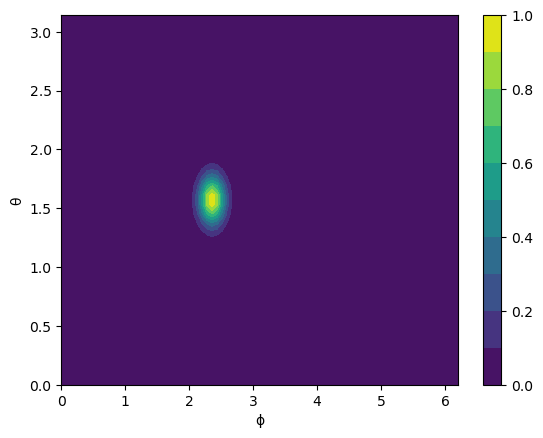

In [5]:
N = 100
psi = cqd.utility.CSS(N, pi / 2, 3 * pi / 4)
thvec, phvec, Hdistr = cqd.utility.Husimi_th_ph(N, psi, 40, 80)
plt.contourf(phvec, thvec, Hdistr, 10)
plt.xlabel('ϕ')
plt.ylabel('θ')
plt.colorbar()
plt.show()

Below are some other examples of how to visualize the collective spin. As an example, we evolve the state under the collective Ising Hamiltonian to see the dynamics of the distribution. Try different atom numbers $N$ and parameter choices $\Omega$. What happens at $\Omega=0.5$? (For the exercises below you will only need to plot points and lines on the Bloch sphere or in a contour plot, so it is not crucial to understand all the code below in detail.)

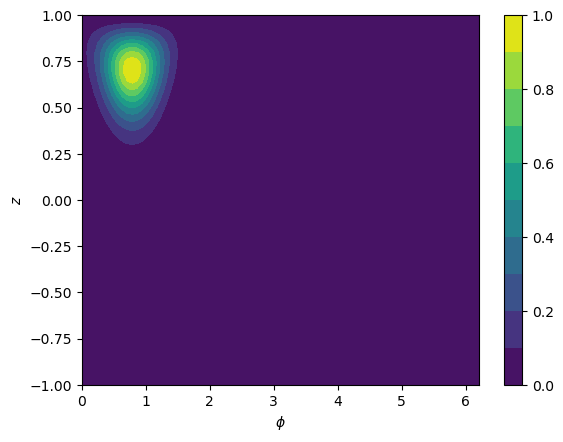

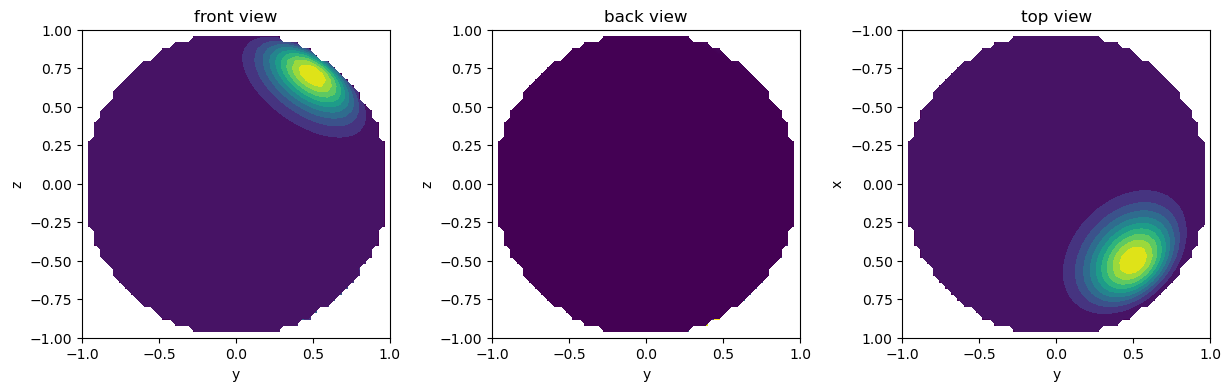

In [6]:
# visualize a coherent spin state

N = 40
psi = cqd.utility.CSS(N, pi / 4, pi / 4) # The state we want to visualize
HscaleMax = 1 # clipping value for colorscale. Will later be useful.

# plot distribution in z and phi
zvec, phvec, Hdistr = cqd.utility.Husimi_z_phi(N, psi, 40, 80)
plt.contourf(phvec, zvec, Hdistr, 10)
plt.colorbar()
plt.xlabel('$\\phi$')
plt.ylabel('$z$')
plt.show()

zvec, yvec, Hfront = cqd.utility.Husimi_front(N, psi, 50, 50)
zvec, yvec, Hback = cqd.utility.Husimi_back(N, psi, 50, 50)
xvec, yvec, Htop = cqd.utility.Husimi_top(N, psi, 50, 50)

cqd.plotting.plot_H_all(Hfront, Hback, Htop, zvec, HscaleMax = 1.0)

In [7]:
# calculate the full quantum dynamics by exact diagonalization and visualize the dynamics
# producing all the Husimi distributions takes a while
N = 100
ome = 0.8
HscaleMax = 0.5
H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)
ini = np.eye(1, N + 1, N)[0]

# diagonalize
evals, evecs = LA.eigh(H_mat.toarray())

# calculate projections on eigenstates
iniProj = cqd.unitaries.init_coeffs_eigenbasis(ini, evecs)

# precalculate Husimi distributions
t1 = 10
dt = 0.2
tsteps = int(t1 / dt)
tvec = cqd.utility.create_tvecs(tsteps, dt)
ngrid = 40
grid = np.linspace(-1, 1, ngrid, endpoint=True)

HfrontAll = np.ma.array(np.zeros((ngrid, ngrid, len(tvec))))
HbackAll =  np.ma.array(np.zeros((ngrid, ngrid, len(tvec))))
HtopAll =  np.ma.array(np.zeros((ngrid, ngrid, len(tvec))))

for it in range(len(tvec)):
    #print(it, end=' ')
    Psit = cqd.unitaries.t_evol_eigenbasis(iniProj, tvec[it], evals, evecs)
    zvec, yvec, HfrontAll[:,:,it] = cqd.utility.Husimi_front(N, Psit, ngrid, ngrid)
    zvec, yvec, HbackAll[:,:,it] = cqd.utility.Husimi_back(N, Psit, ngrid, ngrid)
    zvec, yvec, HtopAll[:,:,it] = cqd.utility.Husimi_top(N, Psit, ngrid, ngrid)    

    
interactive(cqd.plotting.plot_H_wrapper_interact, it=FloatSlider(min=0, max=len(tvec) - 1, step=1), HfrontAll=fixed(HfrontAll), HbackAll=fixed(HbackAll), HtopAll=fixed(HtopAll), grid=fixed(grid), HscaleMax=fixed(HscaleMax))

interactive(children=(FloatSlider(value=0.0, description='it', max=50.0, step=1.0), Output()), _dom_classes=('…

### Exercise 1

Now we want to understand these dynamics better by examining the mean-field trajectories.
The mean-field energy functional reads
$$
E_{MF}/(N/2) = -z^2/2 - \Omega \sqrt{1-z^2}\cos(\phi) 
$$
which leads to the mean-field equations of motion
$$
\dot z = -\Omega \sqrt{1-z^2}\sin(\phi)
$$
$$
\dot \phi = -z + \Omega \frac{z}{\sqrt{1-z^2}}\cos(\phi) 
$$
Plot mean-field energy as a contour plot in $z$ and $\phi$ for different $\Omega$. The mean-field trajectories follow the iso-energy lines. Where are stable and unstable fixed points? Where is the sparatrix between trajectories circling a stable fixed point and the ones rotating around the whole sphere? What happens at $\Omega=0.5$?

The answers to these questions will become more obvious when you solve the mean-field equations. 

Optional: Solve the mean-field equations in $z$ and $\phi$ numerically. (Next we will solve them in the spin components, which is more convenient for truncated Wigner simulations.)

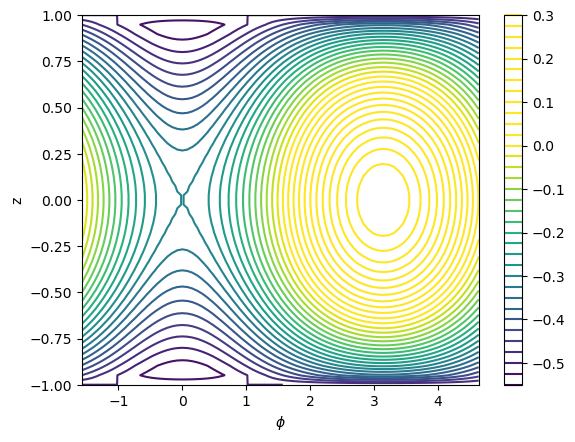

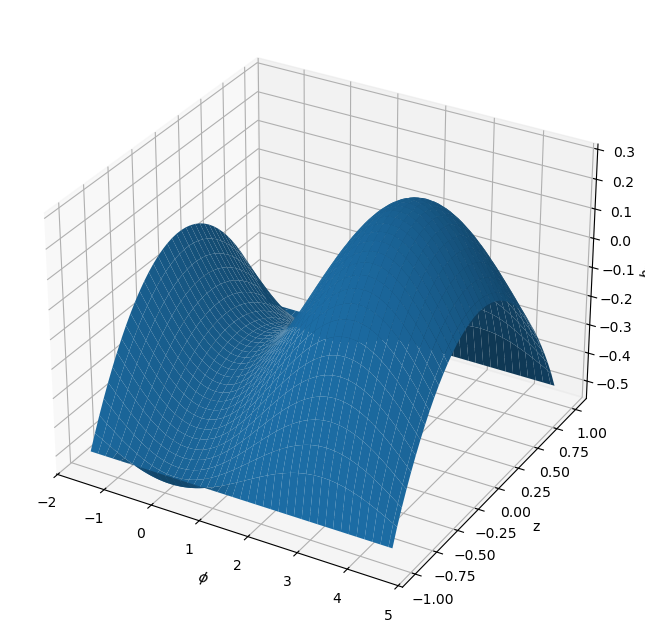

In [8]:
# mean field energy functional

ome = 0.3

# make a grid
nz = 40
nph = 80
z = np.linspace(-1, 1, nz, endpoint=True)
ph = np.linspace(-pi / 2, 3 * pi / 2, nph, endpoint=False)

E_MF_points = np.zeros((len(z), len(ph)))
for i in range(nz):
        E_MF_points[i, :] = cqd.hamiltonians.E_MF(z[i], ph,ome)
        
# set vmax to something small to better resolve regions around minimum
plt.contour(ph, z, E_MF_points, 40, vmax=-.0)
plt.xlabel('$\\phi$')
plt.ylabel('z')
plt.colorbar()
plt.show()

# make a surface plot
fig = plt.figure(figsize=(8, 8))
ax: Axes3D = fig.add_subplot(111, projection="3d")
phgrid, zgrid = np.meshgrid(ph, z)
ax.plot_surface(phgrid, zgrid, E_MF_points)
plt.xlabel('$\\phi$')
plt.ylabel('z')
ax.set_zlabel('$h_{mf}$')
plt.show()

In [9]:
# plot phi=0 section for different omegas
interactive(cqd.plotting.plot_hmf_line, ome=FloatSlider(min=0.2, max=1.5, step=0.05))

interactive(children=(FloatSlider(value=0.2, description='ome', max=1.5, min=0.2, step=0.05), Output()), _dom_…

Some interpretation along the lines of what was discussed in the lecture should be given!

### Exercise 2

In the spin components, the mean-field equations read ($x=S_x/(N/2)$ etc.)
$$
\dot x = yz
$$
$$
\dot y = -xz + \Omega z
$$
$$
\dot z = -\Omega y
$$
Solve these equations using your integrator of choice. (I used SciPy's `integrate.ode` again with the same options as on programming exercise 6. I typically integrate up to `t~10`, however, there are certain initial conditions/$\Omega$-values, for which this will not give closed trajectories... Which ones?)

Plot the trajectories for different initial conditions and different $\Omega$. You can plot them on the Bloch sphere using the Bloch() class or plotting the xz-, yz-, or xy-plane projections. Make sure that the outcome matches your expectations from the mean-field energy functional.

It is instructive to see what changes for the trajectory starting at the north pole (x,y,z) = (0,0,1) when $\Omega$ is increased from below 0.5 to above 0.5.

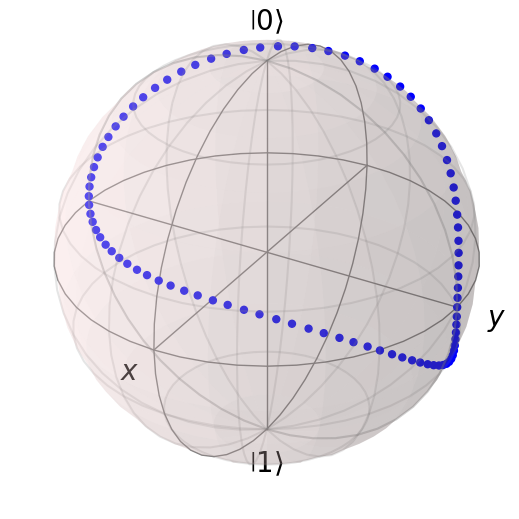

In [10]:
# solve the mean field equations using xyz equations.

# initial conditions
theta = pi / 2
y0, t0 = np.array([np.cos(theta), np.sin(theta), 0]), 0
#y0, t0 = np.array([0, 0, 1]), 0
ome = 0.5

# set up integrator
r = ode(cqd.integrators.TFIM_MF_diff_eq).set_integrator('zvode', method='adams', with_jacobian=False)
r.set_initial_value(y0, t0).set_f_params(ome)

# set time steps
t1 = 18
dt = 0.2
tsteps = int(t1/dt)
tvec = cqd.utility.create_tvecs(tsteps, dt)
trajectory=np.zeros((len(tvec), 3))

# integration
trajectory[0] = y0
i = 1
while r.successful() and r.t < t1  and i<len(tvec):
    r.integrate(r.t+dt)
    trajectory[i] = r.y
    i += 1

bloch = Bloch()
cqd.plotting.plot_trajectory_bloch(len(tvec) - 1, bloch, trajectory)



In [11]:
interactive(cqd.plotting.plot_trajectory_bloch, t_idx=FloatSlider(min=1,max=len(tvec)-1,step=1), bloch=fixed(bloch), trajectory=fixed(trajectory))

interactive(children=(FloatSlider(value=1.0, description='t_idx', max=90.0, min=1.0, step=1.0), Output()), _do…

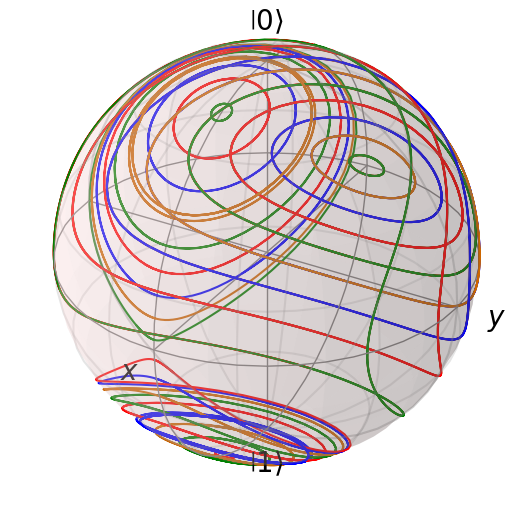

In [12]:
# create a list of initial conditions sampling the sphere densely
ini_list_zph = np.transpose([np.linspace(-1, 1, 20), np.full(20, 0 * pi / 2)])
ini_list_zph = np.append(ini_list_zph,np.transpose([np.linspace(-1, 1, 20), np.full(20, 2 * pi / 2)]),axis=0)
ini_list = np.zeros((len(ini_list_zph), 3))
ini_list[:,2] = ini_list_zph[:,0] # z
ini_list[:,1] = np.sqrt(1 - ini_list_zph[:, 0] ** 2) * np.sin(ini_list_zph[:, 1]) # y
ini_list[:,0] = np.sqrt(1 - ini_list_zph[:, 0] ** 2) * np.cos(ini_list_zph[:, 1]) # x

# define time grid
t1 = 20
dt = 0.2
tsteps = int(t1 / dt)
tvec = cqd.utility.create_tvecs(tsteps, dt)
ome = 0.4

# calculate trajectories for all initial points
all_trajectories = np.zeros((len(ini_list), len(tvec), 3))
for i in range(len(ini_list)):
    all_trajectories[i] = cqd.integrators.get_trajectory(ini_list[i], tvec, ome)

bloch.clear()
for i in range(len(all_trajectories)):
    bloch.add_points(np.transpose(all_trajectories[i,:,:]),meth='l')
bloch.show()


### Exercise 3

Now we are ready to implement the truncated Wigner simulation. Calculate the classical trajectories of a sample of points that is Gaussian-distributed around 0 in x and y (with $\sigma=1/\sqrt{N}$) and has z=1 initially. This corresponds to an initial coherent spin state with $\theta=\phi=0$

1) Plot the TWA outcome on the Bloch sphere: Plot the cloud of points you sampled in an interactive plot. Moderate sample sizes (fewer than 1000) are sufficient here.

2) Compare the outcome of the expectation value of the spin components and their variances to the exact solution. Plot them in the same axes as a function of time. For the expectation values of the spin components, also plot the mean-field solution, i.e. the mean-field trajectory starting at the north pole of the sphere. Use a value of $\Omega$ close to 0.5 where the dynamics is most interesting.

3) Use $N=20$ and $100$ and a number of sampled trajectories of $100$ and $1000$ to see how this influences the performance of TWA. Interpret your results.

Below is an ED code which you can use for comparison to the exact results.

Hints:
Useful functions: `np.random.normal()`, `np.mean()`, `np.var()`
Write a wrapper function that calculates a trajectory for given initial condition and parameters.

In [13]:
# calculate full quantum case for comparing to TWA
N = 100
ome = 0.4
H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)
ini = cqd.utility.CSS(N, 0, 0)

# diagonalize
evals, evecs = LA.eigh(H_mat.toarray())

# calculate projections on eigenstates
iniProj = cqd.unitaries.init_coeffs_eigenbasis(ini, evecs)

# calculate observables
t1 = 10
dt = 0.1
tsteps = int(t1 / dt)
tvec = cqd.utility.create_tvecs(tsteps, dt)
obsExact = np.zeros((len(tvec), 6), dtype=complex)

Sx, Sy, Sz = cqd.operators.build_spin_ops_sparse(N)
spin_op_vec = np.array([Sx, Sy, Sz]) / (N / 2)
spin_op_vec_squared = np.array([Sx @ Sx, Sy @ Sy, Sz @ Sz]) / (N / 2) ** 2
for it in range(len(tvec)):
    Psit = cqd.unitaries.t_evol_eigenbasis(iniProj, tvec[it], evals, evecs)
    obsExact[it, 0:3] = cqd.utility.expectation_value(Psit, spin_op_vec) 
    obsExact[it, 3:6] = cqd.utility.expectation_value(Psit, spin_op_vec_squared) - obsExact[it, 0:3] ** 2

In [14]:
# truncated Wigner: sample the initial condition from Gaussian distribution
# make sure you understand what the following code does...!
n_samples = 1000
xy_ini = np.random.normal(0, 1 / np.sqrt(N), (n_samples, 2)) # Gaussian random numbers for x and y
ini_list = np.transpose([xy_ini[:, 0], xy_ini[:, 1], np.full(n_samples, 1)]) # add constant 1 for z

all_trajectories = np.zeros((len(ini_list), len(tvec), 3))

# loop over initial conditions
t1=time.time()
for i in range(len(ini_list)):
    all_trajectories[i] = cqd.integrators.get_trajectory(ini_list[i], tvec, ome)
t2=time.time()
print("time TWA: ", t2 - t1)

time TWA:  1.6526882648468018


In [15]:
# interactive plot of the distribution on the Bloch sphere
def plotTWA_distr_bloch(it):
    it = int(it)
    b = Bloch()
    b.add_points(np.transpose(all_trajectories[:,it]))
    b.show()

In [16]:
interactive(cqd.plotting.plot_TWA_distr_bloch, t_idx=FloatSlider(min=0,max=len(tvec)-1,step=1), bloch=fixed(bloch), all_trajectories=fixed(all_trajectories))

interactive(children=(FloatSlider(value=0.0, description='t_idx', step=1.0), Output()), _dom_classes=('widget-…

In [17]:
# plot also the mean field result
iniMF = np.array([0,0,1])
MFtraj = cqd.integrators.get_trajectory(iniMF, tvec, ome)

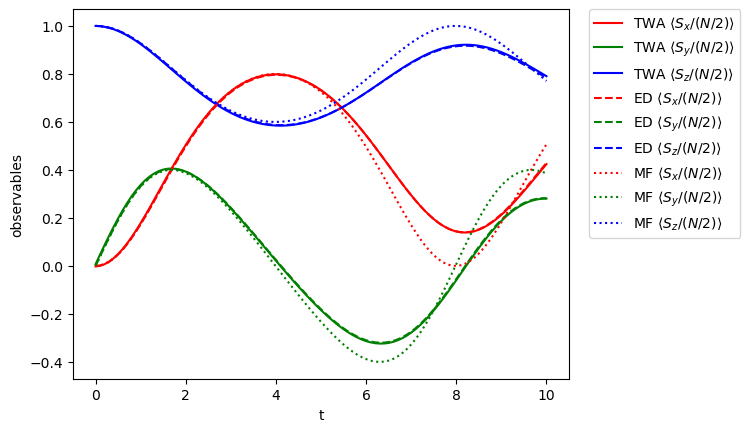

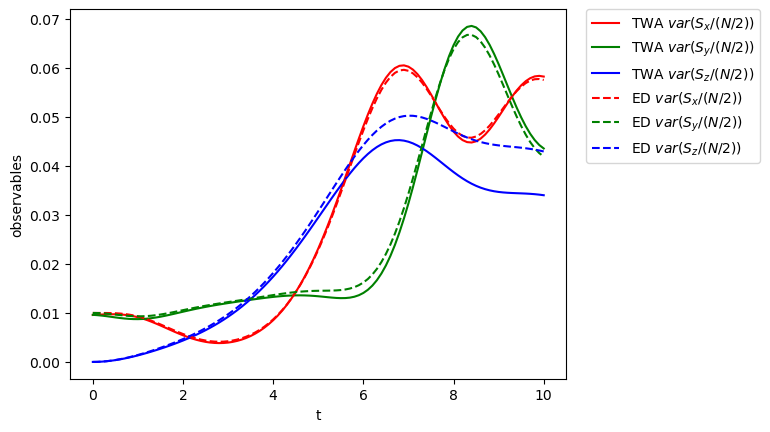

In [18]:
# calculate observables and compare to exact result
# calculate means and variances in all 3 directions
obsTWA = np.zeros((len(tvec),6))
obsTWA[:,0:3] = np.mean(all_trajectories,axis=0)
obsTWA[:,3:6] = np.var(all_trajectories,axis=0)

# print(obsTWA[0,3:6])

# plotting
plt.plot(tvec, obsTWA[:, 0], 'r', label = 'TWA $\\langle S_x/(N/2) \\rangle$')
plt.plot(tvec, obsTWA[:, 1], 'g', label = 'TWA $\\langle S_y/(N/2) \\rangle$')
plt.plot(tvec, obsTWA[:, 2], 'b', label = 'TWA $\\langle S_z/(N/2) \\rangle$')
plt.plot(tvec, obsExact[:, 0], 'r--', label = 'ED $\\langle S_x/(N/2) \\rangle$')
plt.plot(tvec, obsExact[:, 1], 'g--', label = 'ED $\\langle S_y/(N/2) \\rangle$')
plt.plot(tvec, obsExact[:, 2], 'b--', label = 'ED $\\langle S_z/(N/2) \\rangle$')
plt.plot(tvec, MFtraj[:, 0], 'r:', label = 'MF $\\langle S_x/(N/2) \\rangle$')
plt.plot(tvec, MFtraj[:, 1], 'g:', label = 'MF $\\langle S_y/(N/2) \\rangle$')
plt.plot(tvec, MFtraj[:, 2], 'b:', label = 'MF $\\langle S_z/(N/2) \\rangle$')
plt.xlabel('t')
plt.ylabel('observables')
plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.show()

plt.plot(tvec, obsTWA[:, 3], 'r', label = 'TWA $var(S_x/(N/2))$')
plt.plot(tvec, obsTWA[:, 4], 'g', label = 'TWA $var(S_y/(N/2))$')
plt.plot(tvec, obsTWA[:, 5], 'b', label = 'TWA $var(S_z/(N/2))$')
plt.plot(tvec, obsExact[:, 3], 'r--', label = 'ED $var(S_x/(N/2)$)')
plt.plot(tvec, obsExact[:, 4], 'g--', label = 'ED $var(S_y/(N/2)$)')
plt.plot(tvec, obsExact[:, 5], 'b--', label = 'ED $var(S_z/(N/2)$)')
plt.xlabel('t')
plt.ylabel('observables')
plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.show()